In [ ]:
# Setup Thai font for matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!wget -q -O thsarabunnew-webfont.ttf https://github.com/PyThaiNLP/prachathai-67k/raw/master/thsarabunnew-webfont.ttf

fm.fontManager.addfont("thsarabunnew-webfont.ttf")
plt.rc('font', family='TH Sarabun New')

In [ ]:
from datasets import load_dataset
ds = load_dataset("szzs1693/intro-nlp-thai-news")
df = ds["train"].to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/490 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/32.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6603 [00:00<?, ? examples/s]

In [ ]:
%pip install pythainlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 22.1 MB/s eta 0:00:00


In [ ]:
from pythainlp.tokenize import word_tokenize

def tokenize(text: str) -> str:
    tokens = word_tokenize(text, engine="newmm", keep_whitespace=False)
    return " ".join(tokens)

In [ ]:
from tqdm import tqdm
# This cell is slow (~5–10 min depending on hardware). Run once and proceed.
tqdm.pandas(desc="Tokenizing")
df["tokenized_text"] = df["body_text"].progress_apply(tokenize)

Tokenizing: 100%|██████████| 6603/6603 [02:18<00:00, 47.78it/s] 


In [ ]:
# สร้าง composite key เพื่อ stratify ทั้ง category และ source
df["stratify_key"] = df["category"] + "_" + df["source"]

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["stratify_key"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["stratify_key"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 4622
Validation: 990
Test: 991


In [ ]:
X_train = train_df["tokenized_text"]
X_test = test_df["tokenized_text"]

X_val = val_df["tokenized_text"]
y_val = val_df["category"]

y_train = train_df["category"]
y_test = test_df["category"]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=50_000, sublinear_tf=True)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"Train matrix shape: {X_train_tfidf.shape}")

Vocabulary size: 32,002
Train matrix shape: (4622, 32002)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

In [ ]:
%pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.6 MB/s eta 0:00:00


In [ ]:
# Create embedding only for training data
sentences = train_df["tokenized_text"].apply(lambda x: x.split())

from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences,
    vector_size=100,   # ขนาด embedding
    window=5,
    min_count=2,
    workers=4,
    sg=1               # 1 = skip-gram
)

In [ ]:
# Check token length distribution to pick a good max_len
lengths = train_df["tokenized_text"].apply(lambda x: len(x.split()))

print("Token length stats (train set):")
print(lengths.describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]).to_string())

# Proportion of articles that fit within max_len
for threshold in [200, 300, 400, 500]:
    pct = (lengths <= threshold).mean() * 100
    print(f"max_len={threshold}: covers {pct:.1f}% of training articles")

Token length stats (train set):
count     4622.000000
mean       965.355474
std       1103.959472
min         65.000000
50%        652.000000
75%       1105.750000
90%       1872.900000
95%       2704.850000
99%       5766.160000
max      15020.000000
max_len=200: covers 5.1% of training articles
max_len=300: covers 14.0% of training articles
max_len=400: covers 24.8% of training articles
max_len=500: covers 35.2% of training articles


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_df["tokenized_text"])

X_train_seq = tokenizer.texts_to_sequences(train_df["tokenized_text"])
X_val_seq   = tokenizer.texts_to_sequences(val_df["tokenized_text"])
X_test_seq  = tokenizer.texts_to_sequences(test_df["tokenized_text"])

max_len = 700

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, truncating='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, truncating='post')

In [ ]:
import numpy as np

embedding_dim = 100
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

rnn_model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=False),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(len(le.classes_), activation="softmax")
])

rnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     4,793,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,793,800 (18.29 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,793,800 (18.29 MB)

In [ ]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=False),
    LSTM(64),
    Dropout(0.5),
    Dense(len(le.classes_), activation="softmax")
])

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     4,793,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,793,800 (18.29 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,793,800 (18.29 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint_rnn = ModelCheckpoint(
    "best_rnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
)
early_stop_rnn = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint_rnn, early_stop_rnn]
)

Epoch 1/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step - accuracy: 0.3550 - loss: 1.2811 - val_accuracy: 0.3717 - val_loss: 1.3639
Epoch 2/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 21s 142ms/step - accuracy: 0.4658 - loss: 1.1332 - val_accuracy: 0.3899 - val_loss: 1.0790
Epoch 3/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/step - accuracy: 0.4253 - loss: 1.1053 - val_accuracy: 0.5808 - val_loss: 0.9174
Epoch 4/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 21s 147ms/step - accuracy: 0.5602 - loss: 0.9725 - val_accuracy: 0.4535 - val_loss: 1.1346
Epoch 5/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 39s 134ms/step - accuracy: 0.5336 - loss: 0.9823 - val_accuracy: 0.5848 - val_loss: 0.9162
Epoch 6/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 22s 153ms/step - accuracy: 0.5900 - loss: 0.9095 - val_accuracy: 0.5000 - val_loss: 1.0089
Epoch 7/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 19s 133ms/step - accuracy: 0.5576 - loss: 0.9554 - val_accuracy: 0.6636 - val_loss: 0.8153
Epoch 8/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.6486 - loss: 0

In [ ]:
%pip install scikit-learn

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 252ms/step


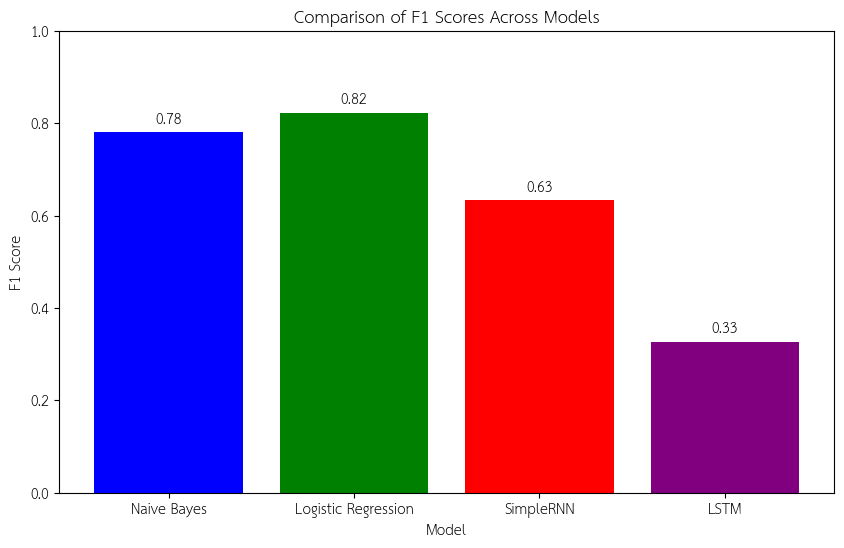

In [ ]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

# Evaluate Naive Bayes model
f1_nb = f1_score(y_test_enc, le.transform(y_pred_nb), average='weighted')

# Evaluate Logistic Regression model
f1_lr = f1_score(y_test_enc, le.transform(y_pred_lr), average='weighted')

# Evaluate RNN model
y_pred_rnn_probs = rnn_model.predict(X_test_pad)
y_pred_rnn = np.argmax(y_pred_rnn_probs, axis=1)
f1_rnn = f1_score(y_test_enc, y_pred_rnn, average='weighted')

# Evaluate LSTM model
y_pred_lstm_probs = lstm_model.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_lstm_probs, axis=1)
f1_lstm = f1_score(y_test_enc, y_pred_lstm, average='weighted')

models = ['Naive Bayes', 'Logistic Regression', 'SimpleRNN', 'LSTM']
f1_scores = [f1_nb, f1_lr, f1_rnn, f1_lstm]

plt.figure(figsize=(10, 6))
plt.bar(models, f1_scores, color=['blue', 'green', 'red', 'purple'])
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.title('Comparison of F1 Scores Across Models')
plt.ylim(0, 1) # F1 score is between 0 and 1
for i, score in enumerate(f1_scores):
    plt.text(i, score + 0.02, f'{score:.2f}', ha='center')
plt.show()